In [1]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import numpy as np

In [2]:
# Загрузка данных из geopackage файла
roads = gpd.read_file('C:/code/Qmaps/graph.gpkg', layer='edges')
roads.head()

,u,v,key,osmid,oneway,lanes,highway,maxspeed,reversed,length,from,to,name,bridge,ref,junction,access,width,tunnel,geometry
0,182686258,2407519699,0,31951798,True,2,primary,60,False,52.470,182686258,2407519699,,,,,,,,"LINESTRING (92.87829 56.06180, 92.87755 56.06157)"
1,182686258,5790834498,0,31951798,True,2,primary,60,False,22.576,5790834498,182686258,,,,,,,,"LINESTRING (92.87860 56.06190, 92.87829 56.06180)"
2,182686259,9410304822,0,180527123,True,2,primary,90,False,1201.661,182686259,9410304822,Северное шоссе,,,,,,,"LINESTRING (92.87652 56.06126, 92.85951 56.05610)"
3,182686259,2063885020,0,31951798,True,2,primary,60,False,47.033,2063885020,182686259,,,,,,,,"LINESTRING (92.87719 56.06146, 92.87652 56.06126)"
4,182686262,182686263,0,180527123,True,2,primary,90,False,54.321,182686262,182686263,Северное шоссе,,,,,,,"LINESTRING (92.85857 56.05585, 92.85776 56.05566)"


In [3]:
print('Количество дорог', len(roads))
roads['highway'].value_counts()

Количество дорог 28763


highway
residential       14651
primary            3662
secondary          3204
tertiary           2215
unclassified       1819
primary_link       1298
trunk              1220
secondary_link      245
living_street       233
tertiary_link       133
trunk_link           83
Name: count, dtype: int64

Собираем граф из узлов и ребер

In [4]:
# Заполняем нулевые значения длины
roads['length'] = roads['length'].fillna(0)

In [5]:
from osmnx import settings, utils
from osmnx._version import __version__
import math

# Спроектируем DataFrame в местную метрическую систему координат
roads_p = ox.project_gdf(roads)

# Создаем пустой граф
metadata = {
        "created_date": utils.ts(),
        "created_with": f"OSMnx {__version__}",
        "crs": settings.default_crs,
    }
G = nx.MultiDiGraph(**metadata)

nodes_dict = {}
node_id = 0


def haversine_distance(coord1, coord2):
    # Радиус Земли в км
    R = 6371.0

    lat1, lon1 = math.radians(coord1[0]), math.radians(coord1[1])
    lat2, lon2 = math.radians(coord2[0]), math.radians(coord2[1])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = math.sin(dlat / 2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    return R * c

# Перебираем все строки с записями фрагментов дорог
for i, road in roads.iterrows():
    geometry = road['geometry']

    # Координаты всех точек в линии
    coords = list(geometry.coords)
    # print(coords)

    # Добавляем узлы в граф
    for coord in coords:
        if not coord in nodes_dict:
            nodes_dict[coord] = node_id
            node_id += 1

        G.add_node(nodes_dict[coord], x = coord[0], y = coord[1])

    # Добавляем ребра в граф
    for coord1, coord2 in zip(coords[:-1], coords[1:]):
        # Важно! Здесь сейчас длина просто берется из данных указанных в участке дороги на карте. НО должна вычисляться!
        length = haversine_distance(coord1, coord2)
        # length = road['length']

        # Добавляем ребра в обе стороны
        if road['oneway'] == False:
            G.add_edge(nodes_dict[coord2], nodes_dict[coord1], highway=road['highway'], oneway=road['oneway'], length=length)
            G.add_edge(nodes_dict[coord1], nodes_dict[coord2], highway=road['highway'], oneway=road['oneway'], length=length)
        else:
            # Добавляем ребро в обратную сторону и в прямую
            if road['reversed']:
                G.add_edge(nodes_dict[coord2], nodes_dict[coord1], highway=road['highway'], oneway=road['oneway'], length=length)
            else:
                G.add_edge(nodes_dict[coord1], nodes_dict[coord2], highway=road['highway'], oneway=road['oneway'], length=length)

print(G.number_of_nodes(), G.number_of_edges())

27044 49839


In [6]:
list(G.edges(data=True))[:10]

[(0, 1, {'highway': 'primary', 'oneway': True, 'length': 0.08220521468410315}),
 (1,
  5,
  {'highway': 'primary', 'oneway': True, 'length': 0.040768533880858784}),
 (2, 0, {'highway': 'primary', 'oneway': True, 'length': 0.03469770526468822}),
 (3, 4, {'highway': 'primary', 'oneway': True, 'length': 1.8908544559266103}),
 (4, 6, {'highway': 'primary', 'oneway': True, 'length': 0.10466598249355512}),
 (5, 3, {'highway': 'primary', 'oneway': True, 'length': 0.07438654401597956}),
 (6, 7, {'highway': 'primary', 'oneway': True, 'length': 0.0901070372712346}),
 (7, 8, {'highway': 'primary', 'oneway': True, 'length': 0.07996416769737205}),
 (8, 9, {'highway': 'primary', 'oneway': True, 'length': 0.09737720519019301}),
 (9,
  10,
  {'highway': 'primary', 'oneway': True, 'length': 0.09584101740232596})]

In [7]:
# Упрощаем граф
g = ox.simplify_graph(G)
for u, v, d in g.edges(data=True):
    if 'osmid' not in d:
        d['osmid'] = None
        
print(g.number_of_nodes(), g.number_of_edges()) 

4505 10846


In [8]:
list(g.nodes(data=True))


[(17, {'x': 92.8500668, 'y': 56.0551271}),
 (20, {'x': 92.8813965, 'y': 56.0626988}),
 (23, {'x': 92.9407368, 'y': 56.0742638}),
 (31, {'x': 92.9550346, 'y': 56.065227}),
 (32, {'x': 92.9551926, 'y': 56.0651505}),
 (33, {'x': 92.9543937, 'y': 56.0648469}),
 (34, {'x': 92.9557364, 'y': 56.0656845}),
 (44, {'x': 92.9391596, 'y': 56.0714047}),
 (45, {'x': 92.9380039, 'y': 56.0708111}),
 (48, {'x': 92.9406566, 'y': 56.0737753}),
 (55, {'x': 92.940646, 'y': 56.0715666}),
 (94, {'x': 92.9388175, 'y': 56.0747365}),
 (114, {'x': 93.0235298, 'y': 56.0626198}),
 (118, {'x': 93.0220211, 'y': 56.0627124}),
 (127, {'x': 93.0230668, 'y': 56.063784}),
 (130, {'x': 93.0236689, 'y': 56.0627391}),
 (135, {'x': 93.025103, 'y': 56.0631911}),
 (140, {'x': 93.0224413, 'y': 56.0647389}),
 (146, {'x': 93.0230285, 'y': 56.0614273}),
 (147, {'x': 93.0230893, 'y': 56.0612271}),
 (157, {'x': 93.0250553, 'y': 56.0604079}),
 (185, {'x': 93.0229459, 'y': 56.0596332}),
 (194, {'x': 93.0267516, 'y': 56.0418147}),
 (19

In [9]:
list(g.edges(data=True))[:10]

[(20,
  2412,
  {'highway': 'primary',
   'oneway': True,
   'length': 0.12675992727220287,
   'geometry': <LINESTRING (92.881 56.063, 92.881 56.063, 92.881 56.062, 92.881 56.062, 92....>,
   'osmid': None}),
 (20,
  4353,
  {'highway': 'primary_link',
   'oneway': True,
   'length': 0.16579628467907268,
   'geometry': <LINESTRING (92.881 56.063, 92.881 56.063, 92.881 56.063, 92.88 56.063, 92.8...>,
   'osmid': None}),
 (23,
  8391,
  {'highway': 'primary',
   'oneway': True,
   'length': 0.48380430462137664,
   'geometry': <LINESTRING (92.941 56.074, 92.94 56.075, 92.939 56.076, 92.938 56.077, 92.9...>,
   'osmid': None}),
 (31,
  32,
  {'highway': 'primary',
   'oneway': False,
   'length': 0.017574270725099723,
   'osmid': None}),
 (31,
  33,
  {'highway': 'secondary',
   'oneway': True,
   'length': 0.07129812200292436,
   'osmid': None}),
 (31,
  12424,
  {'highway': 'primary',
   'oneway': False,
   'length': 0.07517245046200054,
   'geometry': <LINESTRING (92.955 56.065, 92.955 

In [10]:
# Конвертируем узлы и ребра в MultiDiGraph
nodes, edges = ox.graph_to_gdfs(g)
# edges.head()
nodes.head()

,x,y,geometry
osmid,,,
17,92.850067,56.055127,POINT (92.85007 56.05513)
20,92.881396,56.062699,POINT (92.88140 56.06270)
23,92.940737,56.074264,POINT (92.94074 56.07426)
31,92.955035,56.065227,POINT (92.95503 56.06523)
32,92.955193,56.065151,POINT (92.95519 56.06515)


In [11]:
# Получение id узлов, ближайших к координатам
coord1 = (56.0698944,92.9888370)
coord2 = (56.062695,93.022040)
start = ox.distance.nearest_nodes(g, coord1[1], coord1[0], return_dist=False)
finish = ox.distance.nearest_nodes(g, coord2[1], coord2[0], return_dist=False)
# Расчет маршрута
route = ox.routing.shortest_path(g, start, finish,weight='length')
gdf = ox.routing.route_to_gdf(g, route, weight='length')
route_length = gdf['length'].sum()
print(f"Длина маршрута составляет {len(route)} узлов и {route_length} км")

Длина маршрута составляет 2 узлов и 3.690132734050399 км


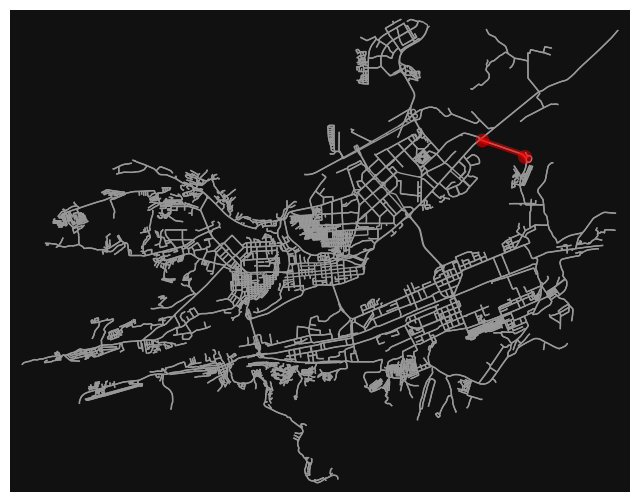

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [12]:
# Маршрут на графе
ox.plot_graph_route(g, route, node_size=0)